<a href="https://colab.research.google.com/github/WoojinCho-Ryan/Studying-Pytorch/blob/main/Transformer_Model_Tutorial_in_PyTorch_From_Theory_to_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[TUTORIAL](https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch)

# Building the Transformer Model with PyTorch

## 1. Importing the necessary libraries and modules

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy

## 2. Defining the basic building blocks: Multi-Head Attention, Position-wise Feed-Forward Networks, Positional Encoding

### Multi-head attention

The multi-head attention mechanism computes the attention between each pair of positions in a sequence. It consists of multiple “attention heads” that capture different aspects of the input sequence.

MHA의 작동 원리는 "분할, 병렬 처리, 결합"의 3단계로 요약할 수 있음.

모델이 입력 시퀀스(sequence)의 여러 부분에 동시에 집중하되, 서로 다른 관점에서 정보를 바라볼 수 있도록 하는 메커니즘.

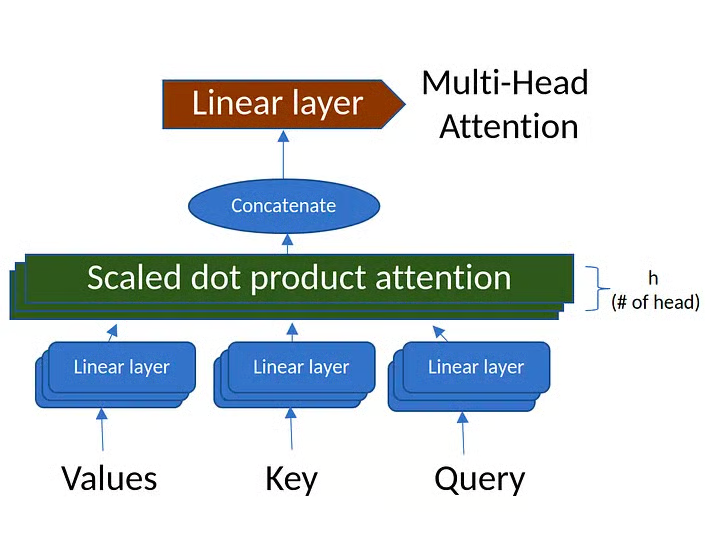


$$Attention(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V$$

In [13]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model, num_heads):
    super(MultiHeadAttention, self).__init__()
    # Ensure: model dimension (d_model) is divisible by the number of heads
    # 단순하게 계산을 편하게 하기 위함이 크다.
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

    # Initialize dimensions
    self.d_model = d_model # Model's dimension
    self.num_heads = num_heads # Num. of attention heads
    self.d_k = d_model // num_heads # Dimension of each head's key, query, and value

    # Linear layers for transforming inputs
    self.W_q = nn.Linear(d_model, d_model) # Query transformation, 검색하려는 단어 또는 질문
    self.W_k = nn.Linear(d_model, d_model) # Key transformation, 사전에 등록된 표제 또는 키워드
    self.W_v = nn.Linear(d_model, d_model) # Value transformation, 각 key에 해당되는 실제 내용
    self.W_o = nn.Linear(d_model, d_model) # Output transformation

  def scaled_dot_product_attention(self, Q, K, V, mask = None):
    # Calculate attention scores
    attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

    # Apply mask if provided (useful for preventing attention to certain parts like padding)
    if mask is not None:
      attn_scores = attn_scores.masked_fill(mask == 0, -1e9)

    # Softmax is applied to obtain attention probabilities (sum to 1.)
    attn_probs = torch.softmax(attn_scores, dim = -1)

    # Multiply by values to obtain the final output
    output = torch.matmul(attn_probs, V)
    return output

  def split_heads(self, x): # This method reshapes the input x into the shape (batch_size, num_heads, seq_length, d_k)
    # Reshape the input to have num_heads for multi-head attention
    batch_size, seq_length, d_model = x.size()
    return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

  def combine_heads(self, x):
    # Combine the multiple heads back to original shape
    batch_size, _, seq_length, d_k = x.size()
    return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

  def forward(self, Q, K, V, mask = None):
    # Apply linear transformations and split heads
    Q = self.split_heads(self.W_q(Q))
    K = self.split_heads(self.W_k(K))
    V = self.split_heads(self.W_v(V))

    # Perform scaled dot-product attention
    attn_output = self.scaled_dot_product_attention(Q, K, V, mask)

    # Combine heads and apply output transformation
    output = self.W_o(self.combine_heads(attn_output))
    return output

### Position-wise feed-forward networks

In [14]:
class PositionWiseFeedForward(nn.Module): # subclass of PyTorch's nn.Module
  def __init__(self, d_model, d_ff): # initialization
    # d_model: Dimensionality of the model's input and output
    # d_ff: Dimensionality of the inner layer in the feed-forward network
    # self.fc1, self.fc2: Two fully connected (linear) layers with input and output dimensions as defined by d_model and d_ff.
    super(PositionWiseFeedForward, self).__init__()
    self.fc1 = nn.Linear(d_model, d_ff)
    self.fc2 = nn.Linear(d_ff, d_model)
    self.relu = nn.ReLU()

  def forward(self, x):
    # x: input to the feed-forward network
    return self.fc2(self.relu(self.fc1(x)))

PositionWiseFeedForward 클래스는 Position-wise Feed-Forward Neural Network를 정의하며, 이 신경망(neural network)은 두 개의 Linear Layer와 그 사이에 위치한 ReLU Activation Function으로 구성됩니다.

Transformer Model의 맥락(context)에서, 이 Feed-Forward Network는 각 Position에 대해 독립적(separately)이면서 동일한 방식(identically)으로 적용됩니다.

이는 Transformer 내부의 Attention Mechanism을 통해 학습된 Feature들을 변환(transform)하는 데 도움을 주며, Attention Output에 대한 추가적인 처리 단계(additional processing step) 역할을 합니다.

### Positional Encoding

Positional Encoding은 입력 Sequence (시퀀스)에 있는 각 Token (토큰)의 Position Information (위치 정보)를 주입(inject)하기 위해 사용됩니다.

이 Encoding은 서로 다른 Frequency (주파수)를 가진 Sine (사인) 함수와 Cosine (코사인) 함수를 사용하여 Positional Encoding을 생성합니다.

In [15]:
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_seq_length):
    # d_model: The dimension of the model's input
    # max_seq_length: max length of the sequence for which positional encodings are pre-computed.
    # pe: tensor filled with zeros, which will be populated with positional encodings
    # position: tensor containing the position indices for each position in the sequence
    # div_term: a term used to scale the position indices in a specific way

    super(PositionalEncoding, self).__init__()

    pe = torch.zeros(max_seq_length, d_model)
    position = torch.arange(0, max_seq_length, dtype = torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * - (math.log(10000.0) / d_model))

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    pe_to_use = self.pe[:, :x.size(1)].to(x.device)
    return x + self.pe[:, :x.size(1)]

PositionalEncoding (위치 인코딩) 클래스는 sequence (시퀀스) 내 tokens (토큰)의 position (위치)에 대한 정보를 추가합니다.

transformer model (트랜스포머 모델)은 self-attention mechanism (셀프 어텐션 메커니즘) 때문에 tokens의 order (순서)에 대한 inherent knowledge (고유한 지식)가 부족합니다. 따라서 이 class (클래스)는 model (모델)이 sequence에서 tokens의 position을 고려할 수 있도록 돕습니다.

사용되는 sinusoidal functions (사인파 함수)는 sequence 내 각 position에 대해 unique and smooth encoding (고유하고 부드러운 인코딩)을 생성하기 때문에, model이 relative positions (상대적인 위치)에 easily learn to attend (쉽게 주목하는 것을 학습)할 수 있도록 선택되었습니다.

## 3. Building the encoder blocks

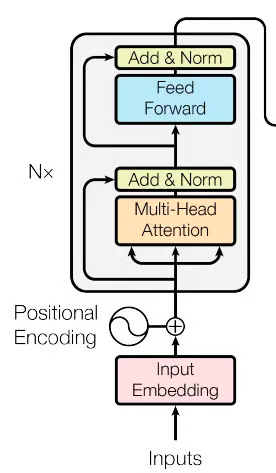

In [16]:
class EncoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, d_ff, dropout):
    super(EncoderLayer, self).__init__()
    self.self_attn = MultiHeadAttention(d_model, num_heads)
    self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
    self.norm1 = nn.LayerNorm(d_model) # applied to smooth the layer's input
    self.norm2 = nn.LayerNorm(d_model)
    self.dropout = nn.Dropout(dropout) # dropout: the dropout rate used for reqularzation
    # dropout layer, used to prevent overfitting by randomly setting some activations to zero during training.

  def forward(self, x, mask): # x: input to the encoder layer, mask: optional to ignore certain parts of the input
    attn_output = self.self_attn(x, x, x, mask)
    x = self.norm1(x + self.dropout(attn_output))
    ff_output = self.feed_forward(x)
    x = self.norm2(x + self.dropout(ff_output))
    return x

EncoderLayer 클래스는 Transformer (트랜스포머)의 Encoder (인코더)에서 단일 Layer (레이어)를 정의합니다.

이 클래스는 Multi-Head Self-Attention Mechanism (멀티 헤드 셀프 어텐션 메커니즘)과 그 뒤에 이어지는 Position-wise Feed-Forward Neural Network (포지션 와이즈 피드 포워드 신경망)를 캡슐화합니다.

이 과정에서 Residual Connections (잔차 연결), Layer Normalization (레이어 정규화), 그리고 Dropout (드롭아웃)이 적절하게 적용됩니다.

이러한 구성 요소들은 함께 작동하여 Encoder가 Input Data (입력 데이터)에서 복잡한 관계를 포착하고, 이를 Downstream Tasks (후속 작업)에 유용한 Representation (표현)으로 변환할 수 있게 합니다. 일반적으로 다수의 이러한 Encoder Layer가 쌓여서 Transformer Model의 완전한 Encoder Part (인코더 부분)를 형성합니다.

## 4. Building the decoder blocks

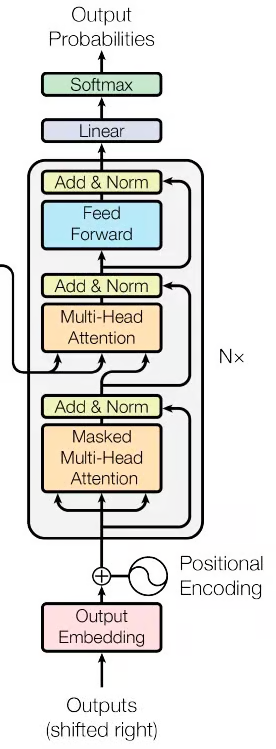

In [17]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))
        attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm2(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))
        return x

DecoderLayer (디코더 레이어) 클래스는 Transformer (트랜스포머)의 Decoder (디코더)에서 단일 Layer (레이어)를 정의합니다.

이 클래스는 Multi-Head Self-Attention Mechanism (멀티 헤드 셀프 어텐션 메커니즘), Multi-Head Cross-Attention Mechanism (멀티 헤드 크로스 어텐션 메커니즘) (이는 Encoder의 output에 attend합니다), Position-wise Feed-Forward Neural Network (포지션 와이즈 피드 포워드 신경망), 그리고 그에 상응하는 Residual Connections (잔차 연결), Layer Normalization (레이어 정규화), Dropout (드롭아웃) layers로 구성됩니다.

이 조합은 Decoder가 Target Sequence (목표 시퀀스)와 Source Sequence (소스 시퀀스)를 모두 고려하여, Encoder의 Representations (표현)을 기반으로 Meaningful Outputs (의미 있는 출력)을 생성할 수 있도록 합니다.

Encoder와 마찬가지로, 다수의 Decoder Layer가 일반적으로 쌓여서 Transformer Model의 완전한 Decoder Part (디코더 부분)를 형성합니다.

## 5. Combining the encoder and decoder layers to create the complete Transformer network

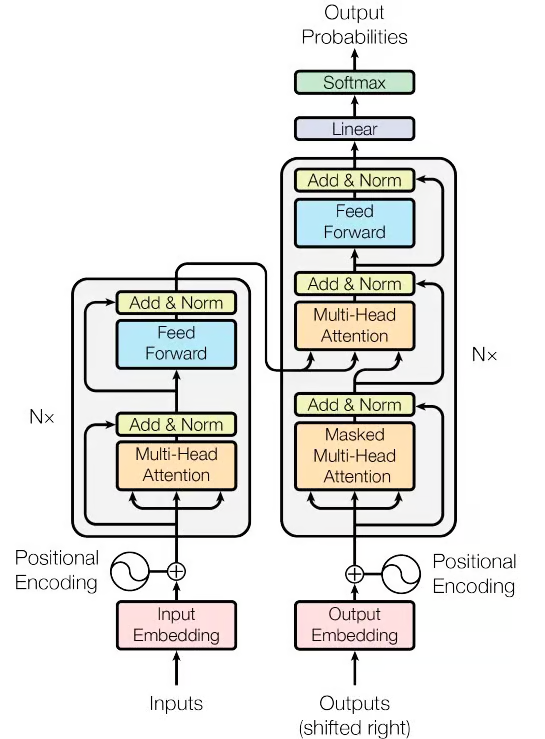

In [18]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout):
      # src_vocab_size: source vocabulary size
      # tgt_vocab_size: target vocabulary size
        super(Transformer, self).__init__()
        # Embedding: transform non-constructed data to dense real-value vector
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model) # embedding layer for the source sequence
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model) # embedding layer for the target sequence
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length) # Positional encoding component

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]) # list of encoder layers
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)]) # list of decoder layers

        self.fc = nn.Linear(d_model, tgt_vocab_size) # final fully connected (linear) layer mapping to target vocabulary size.
        self.dropout = nn.Dropout(dropout) # dropout layer

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)
        tgt_mask = (tgt != 0).unsqueeze(1).unsqueeze(3)
        seq_length = tgt.size(1)
        nopeak_mask = (1 - torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1)).bool()
        tgt_mask = tgt_mask & nopeak_mask
        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

Transformer 클래스는 Embedding (임베딩), Positional Encoding (위치 인코딩), Encoder Layers (인코더 레이어), Decoder Layers (디코더 레이어)를 포함하여 Transformer Model (트랜스포머 모델)의 다양한 구성 요소(components)들을 통합합니다. 이 클래스는 Multi-Head Attention (멀티 헤드 어텐션), Feed-Forward Networks (피드 포워드 네트워크), 그리고 Layer Normalization (레이어 정규화)의 복잡성을 캡슐화(encapsulate)하면서, Training (학습) 및 Inference (추론)를 위한 편리한 Interface (인터페이스)를 제공합니다.

이 Implementation (구현)은 표준 Transformer Architecture (트랜스포머 아키텍처)를 따르며, Machine Translation (기계 번역), Text Summarization (텍스트 요약) 등과 같은 Sequence-to-Sequence Tasks (시퀀스-투-시퀀스 작업)에 적합합니다. Masking (마스킹)을 포함하는 것은 모델이 Sequence 내의 인과 관계(causal dependencies)를 준수하도록 보장하며, Padding Tokens (패딩 토큰)을 무시하고 Future Tokens (미래 토큰)으로부터의 Information Leakage (정보 유출)를 방지합니다.

이러한 순차적인 단계(sequential steps)들은 Transformer Model이 Input Sequences (입력 시퀀스)를 효율적으로 처리하고, 상응하는 Output Sequences (출력 시퀀스)를 생성할 수 있도록 합니다.

# Training the PyTorch Transformer Model

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transformer.to(device)

src_data = src_data.to(device)
tgt_data = tgt_data.to(device)

Using device: cuda


In [20]:
src_vocab_size = 5000
tgt_vocab_size = 5000
d_model = 512 # typically 256, 512, 1024
num_heads = 8 # 8, 12, 16
num_layers = 6 # 6, 12, 24
d_ff = 2048 # 2048, 4096
max_seq_length = 100
dropout = 0.1 # 0.1, 0.3

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)

# Generate random sample data
src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)
tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)

In [21]:
criterion = nn.CrossEntropyLoss(ignore_index = 0)
optimizer = optim.Adam(transformer.parameters(), lr = 0.0001, betas = (0.9, 0.98), eps = 1e-9)

transformer.train()

for epoch in range(100):
    optimizer.zero_grad()

    output = transformer(src_data, tgt_data[:, :-1])

    loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))

    loss.backward()
    optimizer.step()

    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 8.68673324584961
Epoch: 2, Loss: 8.55697250366211
Epoch: 3, Loss: 8.486602783203125
Epoch: 4, Loss: 8.429747581481934
Epoch: 5, Loss: 8.36958122253418
Epoch: 6, Loss: 8.300028800964355
Epoch: 7, Loss: 8.22037124633789
Epoch: 8, Loss: 8.13444709777832
Epoch: 9, Loss: 8.054831504821777
Epoch: 10, Loss: 7.9690117835998535
Epoch: 11, Loss: 7.886897563934326
Epoch: 12, Loss: 7.799063205718994
Epoch: 13, Loss: 7.724514961242676
Epoch: 14, Loss: 7.642771244049072
Epoch: 15, Loss: 7.5542144775390625
Epoch: 16, Loss: 7.470392227172852
Epoch: 17, Loss: 7.377355098724365
Epoch: 18, Loss: 7.30565071105957
Epoch: 19, Loss: 7.228945255279541
Epoch: 20, Loss: 7.15074348449707
Epoch: 21, Loss: 7.065938472747803
Epoch: 22, Loss: 6.989027976989746
Epoch: 23, Loss: 6.913220405578613
Epoch: 24, Loss: 6.82901668548584
Epoch: 25, Loss: 6.755434036254883
Epoch: 26, Loss: 6.683414459228516
Epoch: 27, Loss: 6.610376834869385
Epoch: 28, Loss: 6.5363850593566895
Epoch: 29, Loss: 6.470514297485352

In [22]:
transformer.eval()

# Generate random sample validation data
val_src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)
val_tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)

with torch.no_grad():

    val_output = transformer(val_src_data, val_tgt_data[:, :-1])
    val_loss = criterion(val_output.contiguous().view(-1, tgt_vocab_size), val_tgt_data[:, 1:].contiguous().view(-1))
    print(f"Validation Loss: {val_loss.item()}")

Validation Loss: 8.812225341796875
